In [1]:
import random
import math
from crossover import *
from fitness import *
from initializers import *
from mutation import *
from operations import *
from population import *
from program import *
from selection import *

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

def plot_evolution(population, generation_count, stop_at_fitness):
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = population.evolve(generation_count, stop_at_fitness)
    fig, ax = plt.subplots()
    ax.set_title(F"Best Fitness")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.plot(generations, mins)
    plt.show()
    all_time_best_program.print_readable_code()
    return (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats)

def plot_1d_solution(x_test, y_test, program):
    y_hats = [program.execute(x)[0] for x in x_test]
    fig, ax = plt.subplots()
    ax.plot(x_test, y_test, label="Actual")
    ax.plot(x_test, y_hats, label="Predicted")
    ax.legend()
    plt.show()

def plot_2d_solution(X, Y, Z):
    # x = np.array(x)
    # y = np.array(y)
    # z = np.array(z)
    # X, Y = np.meshgrid(x, y)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0)
    plt.show()


The first example tries to find $f(x)=x^2$

Beginning evolution.
Stopping early. Completed 12/100 generations. Best Fitness: 0.0					
Evolution complete.


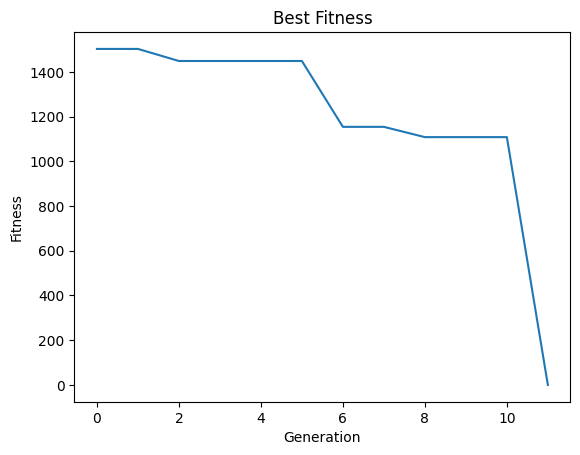

# Register Initialization
r0 = 1.0
r1 = 1.0
r2 = 1.0
r3 = 1.0
r4 = 1.0
r5 = 1.0
r6 = 1.0
r7 = 1.0
r8 = 1.0
r9 = 1.0
read_input_into_registers()
# Start of Program
r3 = not r0
r7 = r0 - r2
r3 = r6 + r9
r0 = r0 ** 2
r8 = r9 ** 2
# End of Program


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [1565.2186834333218,
  1554.867639662278,
  1552.1426901673276,
  1540.9067979114348,
  1527.6412086858443,
  1506.3447103693447,
  1491.9538349484692,
  1466.8966632312984,
  1434.6990593631533,
  1399.1556215807982,
  1307.4625218171586,
  1190.925720539065],
 [1502.7845083491443,
  1502.7845083491443,
  1448.7811413457775,
  1448.7811413457775,
  1448.7811413457775,
  1448.7811413457775,
  1154.242420807057,
  1154.242420807057,
  1108.2390538036898,
  1108.2390538036898,
  1108.2390538036898,
  0.0],
 0.0,
 [[], [], [], [], [], [], [], [], [], [], [], []])

In [3]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional]#, IfThenGoBack]
x_train = np.linspace(0, 10, 100)
y_train = x_train ** 2
x_train = x_train.tolist()
y_train = y_train.tolist()
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.00)
program_mutation_rate = 1.0
crossover_rate = 0.95
instruction_count = 5
register_count = 10
output_value_count = 1
register_initializer = RI_always_one
crossover_func=standard_crossover_2pt()
survival_selection_func = binary_tournament_selection
lam = 100
nu = 50
mu = 100



pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=True)

plot_evolution(pop, 100, 0.0)

The next example tries to find $f(x,y)=(y,x)$.

Beginning evolution.
Stopping early. Completed 11/100 generations. Best Fitness: 9.977167705452764e-06					
Evolution complete.


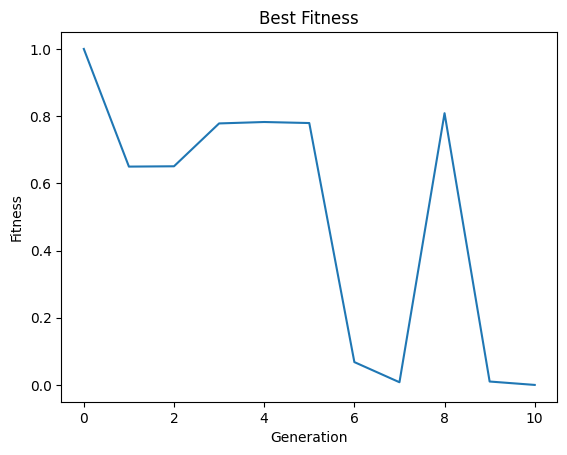

# Register Initialization
r0 = 0.9988914387731938
r1 = 1.0058772721819844
r2 = 0.9898385527250063
r3 = 1.003114595518825
r4 = 1.0087632317852515
r5 = 1.0001923857115187
r6 = 1.0031586654943905
r7 = 1.001412894752201
r8 = 0.9986607432758142
r9 = 1.0044573164915778
read_input_into_registers()
# Start of Program
r7 = r0 * r6
r0 = r1 or r4
r1 = r3 and r7
if r0:
r9 = ln(|r0|)
# End of Program


In [6]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional]#, IfThenGoBack]
x1_train = np.linspace(0, 10, 100).tolist()
x2_train = [50 * random.random() for i in range(100)]
x_train = [(x1_train[i],x2_train[i]) for i in range(100)]
y_train = [(x2,x1) for (x1,x2) in x_train]
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.001)
program_mutation_rate = 1.0
crossover_rate = 0.95
instruction_count = 5
register_count = 10
output_value_count = 2
register_initializer = RI_always_one
crossover_func=standard_crossover_1pt()
survival_selection_func = None
lam = 100
nu = 50
mu = 100



pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=False)

plot_evolution(pop, 100, 0.0001)

Beginning evolution.
Completed 7/100 generations. Best Fitness: 28.01178365294272					

c:\Users\Patri\source\repos\LGP\fitness.py:14: RuntimeWarning: overflow encountered in square
  error += (y - y_hat) ** 2


Completed 100/100 generations. Best Fitness: 23.015150656309725					
Evolution complete.


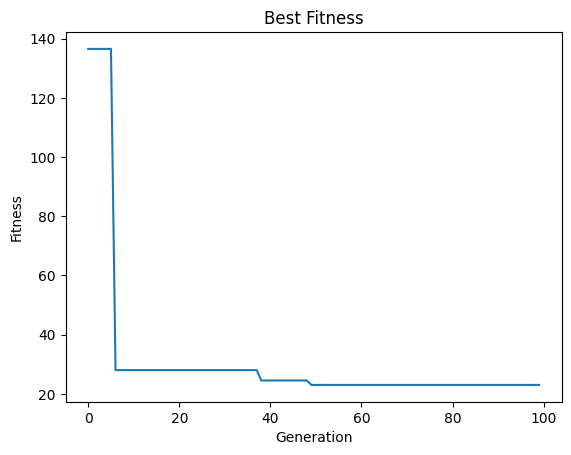

# Register Initialization
r0 = 1.0
r1 = 1.0
r2 = 1.0
r3 = 1.0
r4 = 1.0
r5 = 1.0
r6 = 1.0
r7 = 1.0
r8 = 1.0
r9 = 1.0
read_input_into_registers()
# Start of Program
r0 = r0 - r2
r4 = r7 + r2
r5 = r8 and r4
r1 = r0 ** 2
r0 = r5 + r1
# End of Program


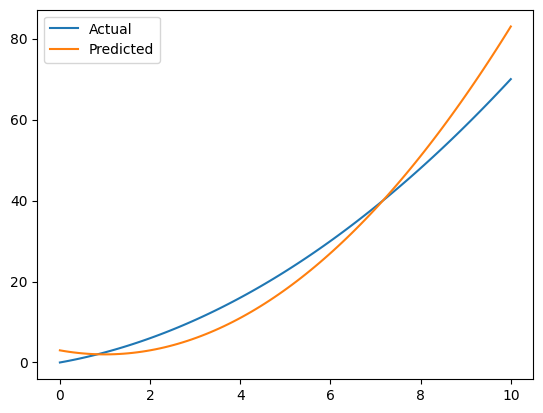

In [8]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional]#, IfThenGoBack]
x_train = np.linspace(0, 10, 100).tolist()
y_train = [0.5 * x**2 + 2 * x for x in x_train]
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.0)
program_mutation_rate = 1.0
crossover_rate = 0.95
instruction_count = 5
register_count = 10
output_value_count = 1
register_initializer = RI_always_one
crossover_func=standard_crossover_1pt()
survival_selection_func = binary_tournament_selection
lam = 1000
nu = 500
mu = 1000



pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=True)

(generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 100, 0.0001)
plot_1d_solution(x_train, y_train, all_time_best_program)

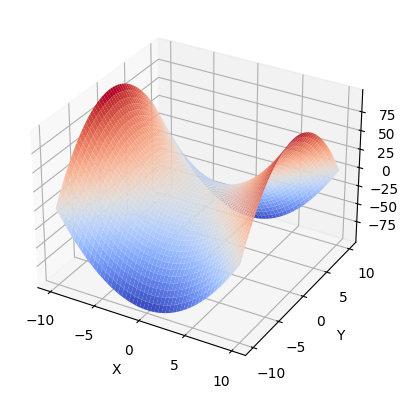

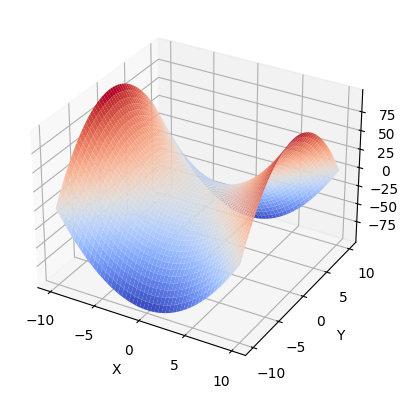

In [19]:
x_train = np.linspace(-10, 10, 1000)
y_train = np.linspace(-10, 10, 1000)
# z = np.array(z)
X, Y = np.meshgrid(x_train, y_train)
Z = X ** 2 - Y ** 2
plot_2d_solution(X, Y, Z)

operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot]
program = Program(10, 5, 1, operations, RI_always_one)
program.instructions[0] = [Square, 0, 0, 0]
program.instructions[1] = [Multiplication, 1, 1, 1]
program.instructions[2] = [Subtraction, 0, 0, 1]
for i in range(3,10):
    # Useless but harmless instruction
    program.instructions[i] = [Addition, 3, 4, 4]

z_hat = np.array([[program.execute(x,y) for x in x_train] for y in y_train]).squeeze(2)
plot_2d_solution(X, Y, z_hat)

In [ ]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional]#, IfThenGoBack]
x1_train = np.linspace(-10, 10, 100)
x2_train = np.linspace(-10, 10, 100)
x_train = [(x1,x2) for x2 in x2_train for x1 in x1_train]
y_train = [x1**2-x2**2 for (x1,x2) in x_train]
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.001)
program_mutation_rate = 1.0
crossover_rate = 0.95
instruction_count = 5
register_count = 10
output_value_count = 2
register_initializer = RI_always_one
crossover_func=standard_crossover_1pt()
survival_selection_func = None
lam = 100
nu = 50
mu = 100



pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=False)

x1_test = np.linspace(-10, 10, 1000)
x2_test = np.linspace(-10, 10, 1000)


X1,X2 = np.meshgrid(x1_test, x2_test)
(generations, means, mins, all_time_best_fitness, all_time_best_program) = plot_evolution(pop, 100, 0.0001)
y_hat = np.array([[program.execute(x1,x2) for x1 in x1_test] for x2 in x2_test]).squeeze(2)
plot_2d_solution(X1, X2, y_hat)


Beginning evolution.
Completed 0/100 generations. Best Fitness: inf					

KeyboardInterrupt: 

Beginning evolution.
Completed 100/100 generations. Best Fitness: 0.49499999999999994					
Evolution complete.


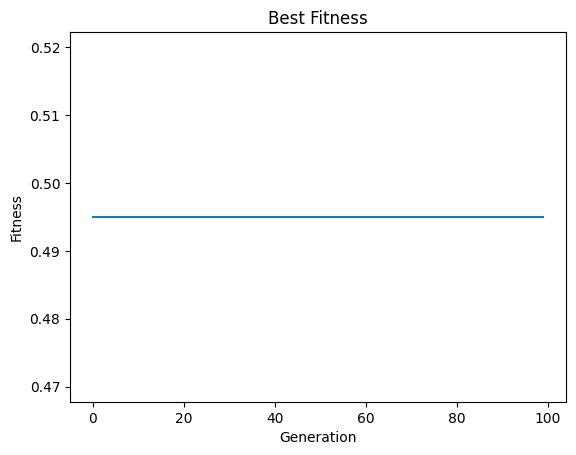

# Register Initialization
r0 = 1.0
r1 = 1.0
r2 = 1.0
r3 = 1.0
r4 = 1.0
read_input_into_registers()
# Start of Program
r2 = r0 or r4
r0 = r4 - r1
if r1:
r4 = r1 and r1
r4 = r4 ** 2
r1 = r2 or r2
r4 = sqrt(|r4|)
r1 = r4 or r1
r4 = r1 / r0
r2 = r0 or r2
# End of Program


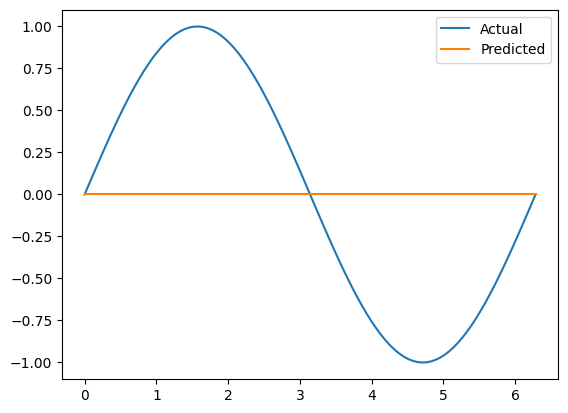

In [5]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Conjunction, Disjunction, LogicalNegation, Conditional]#, IfThenGoBack]
x_train = np.linspace(0, 2*math.pi, 100)
y_train = np.sin(x_train)
x_train = x_train.tolist()
y_train = y_train.tolist()
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
mutation_func = standard_mutation(operations, 0.25, 0.0)
program_mutation_rate = 0.05
crossover_rate = 0.95
instruction_count = 10
register_count = 5
output_value_count = 1
register_initializer = RI_always_one
crossover_func=standard_crossover_2pt()
survival_selection_func = binary_tournament_selection
lam = 100
nu = 50
mu = 100

pop = Population(lam, nu, mu, selection_func, mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=True)

(generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 100, 0.0001)

plot_1d_solution(x_train, y_train, all_time_best_program)